<a href="https://colab.research.google.com/github/2101juli-maker/Visi-n-Artificial/blob/main/Simulaci%C3%B3n_paracaidas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

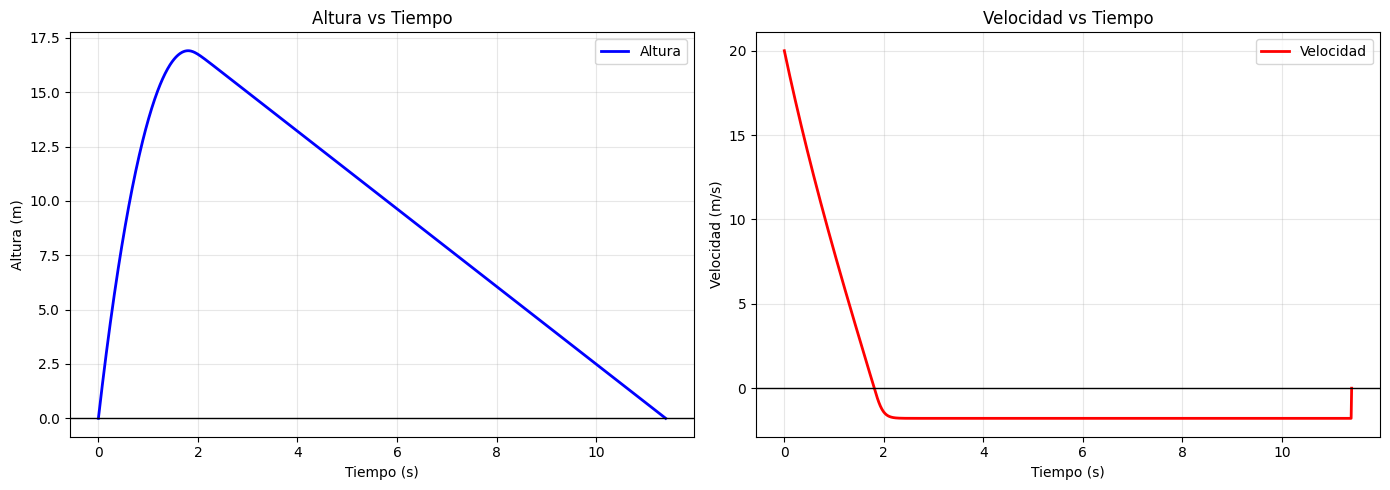

=== RESULTADOS DE LA SIMULACIÓN ===
Altura máxima alcanzada: 16.91 m
Tiempo total de vuelo:   11.40 s
Velocidad de impacto:    1.79 m/s
Estado del paracaídas: DESPLEGADO EXITOSAMENTE


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. PARÁMETROS DEL COHETE (¡MODIFICA ESTOS VALORES!)
# ==========================================================
m = 0.150          # Masa total del cohete con agua (kg)
v0 = 20.0          # Velocidad inicial al terminar la fase de agua (m/s)
g = 9.81           # Gravedad (m/s^2)
rho = 1.225        # Densidad del aire al nivel del mar (kg/m^3)

# Cuerpo del cohete (sin paracaídas)
Cd_cuerpo = 0.5    # Coeficiente de arrastre del cohete (típico: 0.3 a 0.5)
diametro_cuerpo = 0.08 # Diámetro del cohete (m), ej: 8 cm
A_cuerpo = np.pi * (diametro_cuerpo / 2)**2 # Área transversal (m^2)

# Paracaídas
Cd_para = 1.5      # Coeficiente de arrastre del paracaídas (típico: 1.5 para semiesférico)
diametro_para = 0.8 # Diámetro del paracaídas desplegado (m)
A_para = np.pi * (diametro_para / 2)**2 # Área del paracaídas (m^2)

h_deploy = 0       # Altura a la que se abre el paracaídas (0 = justo en el ápice/altura máxima)

# ==========================================================
# 2. SIMULACIÓN (Método numérico de Euler)
# ==========================================================
dt = 0.01          # Paso de tiempo (s). Menor = más preciso
t_max = 20         # Tiempo máximo de simulación (s)
t = np.arange(0, t_max, dt)

# Arrays para guardar los datos en cada paso de tiempo
y = np.zeros_like(t) # Altura
v = np.zeros_like(t) # Velocidad
a = np.zeros_like(t) # Aceleración

y[0] = 0.0         # Altura inicial (suelo)
v[0] = v0          # Velocidad inicial

parachute_open = False

for i in range(1, len(t)):
    # Condición para abrir el paracaídas: cuando empieza a caer (v < 0) y está por encima de h_deploy
    if v[i-1] < 0 and y[i-1] > h_deploy and not parachute_open:
        parachute_open = True

    # Seleccionar área y coeficiente de arrastre según el estado
    if parachute_open:
        Cd = Cd_para
        A = A_para
    else:
        Cd = Cd_cuerpo
        A = A_cuerpo

    # Fuerza de arrastre: Fd = -0.5 * rho * v * |v| * Cd * A
    # El término v * |v| asegura que la fuerza SIEMPRE se oponga al movimiento
    Fd = -0.5 * rho * v[i-1] * abs(v[i-1]) * Cd * A

    # Segunda Ley de Newton: F_neta = m * a  =>  (-m*g + Fd) = m * a
    a[i] = (-m * g + Fd) / m

    # Actualizar velocidad y posición
    v[i] = v[i-1] + a[i] * dt
    y[i] = y[i-1] + v[i] * dt

    # Detener simulación si toca el suelo
    if y[i] <= 0 and i > 1:
        impacto_v = abs(v[i-1]) # Guardar velocidad justo antes de tocar el suelo
        y[i] = 0
        v[i] = 0
        a[i] = 0
        # Recortar arrays para que la gráfica termine exactamente en el suelo
        t = t[:i+1]
        y = y[:i+1]
        v = v[:i+1]
        a = a[:i+1]
        break

# ==========================================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================================
plt.figure(figsize=(14, 5))

# Gráfica de Altura
plt.subplot(1, 2, 1)
plt.plot(t, y, 'b-', linewidth=2, label='Altura')
plt.title('Altura vs Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Altura (m)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfica de Velocidad
plt.subplot(1, 2, 2)
plt.plot(t, v, 'r-', linewidth=2, label='Velocidad')
plt.title('Velocidad vs Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# 4. DATOS CLAVE PARA EL INFORME
# ==========================================================
print("=== RESULTADOS DE LA SIMULACIÓN ===")
print(f"Altura máxima alcanzada: {max(y):.2f} m")
print(f"Tiempo total de vuelo:   {t[-1]:.2f} s")
print(f"Velocidad de impacto:    {impacto_v:.2f} m/s")
if parachute_open:
    print("Estado del paracaídas: DESPLEGADO EXITOSAMENTE")
else:
    print("Estado del paracaídas: NO SE DESPLEGÓ")